# Superdataset Feature Analysis - Predict Item 20
### Predict Item 20 (All things considered, how fearful are you of having dental work done?) from DFS 1-19  
**Notes** 
* See `superdataset-feature-analysis-total-score` notebook for some descriptive statistics on the data.
* Regression models (e.g., Lasso) are not appropriate for predicting Likert values. The data is not continous, e.g., the gap between 1-2 may not be the same as the gap between 4-5.
* The DFS data is skewed. In general, there are more lower values than higher ones. This can be an issue for models that assume normal distribution.
* Models recomended by Claude (sonnet-4.6) to try:
  * Logistic regression as a fast baseline before trying heavier models. Check if LR gets a reasonable kappa (> 0.3).
  * LogisticAT (see https://pythonhosted.org/mord/)
  * LightGBM
  * GradientBoostingClassifier
  * BalancedRandomForest
  * XGBoost

### Summary of model predictions.

| Model | Accuracy | F1 Score (macro)| Cohen Kappa Score (quadradic)|
|:---|:---:|:---:|:---|
| Logistic Regression | 0.66 | 0.55 | 0.85 |
| LogisticAT | 0.65 | 0.56 | 0.85 |
| LightGBM | 0.67 | 0.59 | 0.84 |
| GradientBoostingClassifier | 0.65 | 0.56 | 0.83 |
| BalancedRandomForest | 0.67 | 0.59 | 0.84 |
| XGBoost | 0.67 | 0.59 | 0.84 |

### Understanding the Evaluation Metrics

**Accuracy** is the proportion of respondents whose response was predicted exactly. Every error counts the same, whether the prediction is one level off (4 instead of 5) or four levels off (1 instead of 5). Because it is computed over all respondents, the most common response levels dominate it.

**Macro F1 score** is computed separately for each response level and then averaged, so each level counts equally regardless of how many respondents gave it. For each level, F1 combines *precision* (of the respondents predicted at that level, how many really were) and *recall* (of the respondents at that level, how many were predicted correctly). Rare or hard-to-separate levels pull the macro F1 down, even when overall accuracy is good.

**Cohen Kappa Score (quadratic weighted kappa - QWK)** measures agreement between predicted and actual responses beyond what chance would produce. It penalizes errors by the square of their distance, so a prediction two levels off costs four times as much as one level off. It ranges from −1 to 1, where 0 is chance-level agreement and 1 is perfect agreement. QWK is the most appropriate of the three for an ordinal Likert target, because it recognizes that predicting 4 for a true 5 is a smaller mistake than predicting 1.

### Why the scores differ

- **Accuracy (0.65–0.67) is higher than macro F1 (0.55–0.59)** because of class imbalance. Accuracy is dominated by the common response levels, while macro F1 weights every level equally, so the rarer levels and the overlapping middle levels pull it down.
- **QWK (0.83–0.85) is the highest of the three** because most errors are near misses between adjacent response levels, which QWK penalizes only lightly. Values above 0.80 indicate strong agreement between predicted and actual responses.
- **Differences between models are small.** They are at most 0.02 for accuracy and QWK and 0.04 for F1, so they likely reflect which respondents ended up in the test set rather than real differences in model quality.
- **The two linear models score highest on QWK (0.85)** but slightly lower on macro F1 (0.55–0.56). The tree-based models (LightGBM, BalancedRandomForest, XGBoost) recover the rarer levels slightly better (F1 0.59), but their predictions are no closer to the true response on the ordinal scale.

### Model Comparison and Recommendation

**Recommended model: LogisticAT**

- **It is tied for the highest QWK (0.85)**, the most appropriate metric for an ordinal Likert target, and its accuracy (0.65) is within 0.02 of the best model.
- **It is designed for ordinal outcomes.** It treats the response scale as ordered and estimates a single coefficient per item, interpreted as a shift up or down the scale. Its results are simpler to interpret and report than the per-class results of the multiclass models.
- **The tree-based ensembles gain only 0.03 in macro F1**, which does not justify their added complexity and their reliance on SHAP for interpretation.

**Alternative:** Logistic Regression performs nearly identically. It is a reasonable choice if a familiar, standard model is preferred, but it ignores the ordering of the responses.


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# keeps warnings from printing
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore')# suppress all warnings
# if you want more targeted:
# warnings.filterwarnings('ignore', category=FutureWarning)
# warnings.filterwarnings('ignore', category=ConvergenceWarning)

In [3]:
import pandas as pd
import numpy as np
from lib.superdataset_utils import load_dfs_subset, DFS_QUESTION_COLS
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import textwrap
import random
import sklearn
from sklearn.model_selection import RandomizedSearchCV, train_test_split, StratifiedKFold
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import \
    confusion_matrix, classification_report, cohen_kappa_score, balanced_accuracy_score, accuracy_score, f1_score, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import randint, uniform, loguniform, spearmanr
import xgboost as xgb
import lightgbm as lgb
import shap
from mord import LogisticAT

In [4]:
print(f'sklearn version: {sklearn.__version__}')
print(f'xgb version: {xgb.__version__}')
print(f'pandas version: {pd.__version__}')
print(f'numpy version: {np.__version__}')
print(f'shap version: {shap.__version__}')

sklearn version: 1.9.1
xgb version: 3.1.3
pandas version: 2.3.3
numpy version: 2.4.6
shap version: 0.50.0


---

## Load superdataset

In [5]:
super_df = load_dfs_subset('./DFA-data/merged_dfa_data_cleaned_2026_09_17.csv')
super_df.shape

(4250, 28)

In [6]:
super_df.head()

,Participant_id,Last_Dental_Visit,Sex,Age,dfs1,dfs2,dfs3,dfs4,dfs5,dfs6,...,dfs15,dfs16,dfs17,dfs18,dfs19,dfs20,dfs_avoidance_fear,dfs_specific_stimuli_fear,dfs_physiological_arousal,dfs_total_score
0,1,1,2,44,3,3,4,5,5,1,...,5,5,5,5,1,5,18,26,20,69
1,2,1,2,56,1,1,3,1,1,1,...,2,4,4,4,1,1,8,17,7,33
2,3,1,2,72,1,1,1,1,1,1,...,3,1,1,1,1,1,8,11,5,25
3,6,1,2,36,1,1,1,1,1,1,...,3,3,3,3,1,1,8,16,5,30
4,7,1,2,39,1,1,1,1,1,1,...,1,2,2,2,1,1,8,9,5,23


In [7]:
# subset data to dfs questions
subset_df = super_df[DFS_QUESTION_COLS]
subset_df.shape

(4250, 20)

In [8]:
subset_df.head()

,dfs1,dfs2,dfs3,dfs4,dfs5,dfs6,dfs7,dfs8,dfs9,dfs10,dfs11,dfs12,dfs13,dfs14,dfs15,dfs16,dfs17,dfs18,dfs19,dfs20
0,3,3,4,5,5,1,5,2,2,2,2,2,2,5,5,5,5,5,1,5
1,1,1,3,1,1,1,1,1,1,1,1,1,1,2,2,4,4,4,1,1
2,1,1,1,1,1,1,1,1,1,1,1,1,1,4,3,1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,1,1,1,3,3,3,3,3,1,1
4,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,2,2,2,1,1


---

## Create train and test data

In [9]:
X = subset_df.drop('dfs20', axis=1)
y = subset_df['dfs20']

In [10]:
# note the use of `stratify=y` so every response level is represented in the test set.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42, stratify=y)
print(f'len(X_train): {len(X_train)}, len(y_train): {len(y_train)}')
print(f'len(X_test): {len(X_test)}, len(y_test): {len(y_test)}')

len(X_train): 2847, len(y_train): 2847
len(X_test): 1403, len(y_test): 1403


**note**: the data is skewed

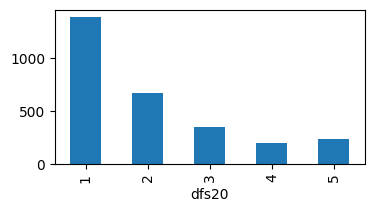

In [11]:
plt.figure(figsize=(4, 2)) # width, height in inches
y_train.value_counts().sort_index().plot(kind='bar')
plt.show()

---

## Logistic Regression  
Check if LR gets a reasonable kappa (> 0.3).

In [12]:
lr_param_dist = {
    'C': loguniform(0.001, 100),  # inverse regularization, log scale is important
    'solver': ['lbfgs', 'saga'],  # both support multinomial
}

In [13]:
lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    param_distributions=lr_param_dist,
    n_iter=20,
    cv=3,
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [14]:
lr_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'C': <scipy.stats....t 0x1287542d0>, 'solver': ['lbfgs', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_result

In [15]:
lr_model = lr_search.best_estimator_

In [16]:
lr_best_score = lr_search.best_score_
lr_best_params = lr_search.best_params_

In [17]:
print("Best LR balanced_accuracy score:", lr_best_score) # 0.55 – 0.70 is a moderate score
print("Best LR params:", lr_best_params)

Best LR balanced_accuracy score: 0.5860910206451276
Best LR params: {'C': np.float64(0.0745934328572655), 'solver': 'lbfgs'}


In [18]:
lr_model.fit(X_train, y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",np.float64(0.0745934328572655)
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, de

In [19]:
y_pred = lr_model.predict(X_test)

### classification report

In [20]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.87      0.82      0.84       684
           2       0.52      0.55      0.53       331
           3       0.39      0.40      0.40       174
           4       0.33      0.43      0.37       100
           5       0.66      0.57      0.61       114

    accuracy                           0.66      1403
   macro avg       0.55      0.55      0.55      1403
weighted avg       0.67      0.66      0.66      1403



In [21]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.66
Macro F1:              0.55
Weighted F1:           0.66
Micro F1:              0.66
Within ±1 accuracy:    0.96
Quadratic weighted κ:  0.85


**Observation**  
The f1 score (0.55 macro avg)is so-os, but the kappa seems meaningful (0.85).  

**Explanation for Claude (sonnet-4.6)**  
* F1 (macro) treats all classes equally — your minority classes (4 and 5 with only 98 and 112 samples) are dragging the average down because they are hard to predict
* Quadratic kappa gives partial credit for near-misses — predicting 3 when the true value is 4 is penalized less than predicting 1 when the true value is 4

**Key observations**  
* Class 3 is the hardest — this is expected and common with Likert data. Middle values are genuinely ambiguous and get pulled toward both lower and higher classes.
* Class 4 is the weakest — only 98 samples and squeezed between 3 and 5. The model likely confuses it with both neighbors.
* Class 5 outperforms class 4 despite similar size — this suggests class 5 has a distinct pattern in the features that the model can detect, even with limited samples.
* Weighted F1 (0.66) vs macro F1 (0.55) — the gap confirms the imbalance is pulling macro down. Weighted F1 is arguably more meaningful for your use case.

**Combined with kappa=0.8 this tells you:**  
The model is making ordinal sense — when it is wrong it is wrong by one step, not wildly off. That is exactly what you want for Likert prediction.

**In the future, perhaps try:**  
Class 4 with only 100 samples is the weak point. You could specifically oversample it:  
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(sampling_strategy={4: 200}, random_state=42  
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)  
This only oversamples class 4 to 200 samples while leaving others unchanged, which may improve that F1 without hurting the other classes.  

### confusion matrix

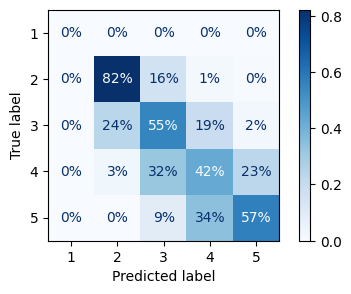

In [22]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

## Interpreting the Confusion Matrix

The confusion matrix compares the model's predicted `dfs20` responses (columns) with the actual responses (rows) on the test set. The train/test split was **stratified by response level** (`stratify=y`) so that each response appears in the test set in proportion to its frequency in the full dataset. Values are **row-normalized**: each cell is the proportion of respondents with a given actual response who were assigned each predicted response. The diagonal cells are therefore the **per-class recall**, the share of each response level the model predicted correctly.

### Key observations

**1. Response 1 is too rare to evaluate.**
Even with stratification, the test set contains no respondents who answered 1, and the model never predicts 1. This response is extremely uncommon in the data. As a result, the large SHAP importance for class 0 (Likert 1) most likely reflects the model pushing predictions *away* from a rare class, not recognizing it well.

**2. Errors are almost always off by one.**
Nearly all misclassifications fall in the cells directly next to the diagonal. The model has captured the ordinal structure of the scale even though it was trained as an unordered multiclass classifier.

| Actual response | Exact match | Within ±1 |
|:---:|:---:|:---:|
| 2 | 82% | 98% |
| 3 | 55% | 98% |
| 4 | 42% | 97% |
| 5 | 57% | 91% |

**3. Performance varies by response level.**
- **Response 2** is predicted most accurately (82%). Most errors are predictions of 3 (16%).
- **Response 3** is correct 55% of the time, with errors split between 2 (24%) and 4 (19%).
- **Response 4** is now the hardest to predict (42%). Its errors fall on both sides: 32% predicted as 3 and 23% as 5.
- **Response 5** is correct 57% of the time. Most errors are predictions of 4 (34%).

**4. Effect of stratification.**
Compared with the non-stratified split, recall for response 5 rose from 45% to 57% and recall for response 4 fell from 54% to 42%. The model no longer strongly underpredicts the top of the scale. Instead, the adjacent responses 4 and 5 are harder to tell apart. Performance for responses 2 and 3 barely changed.

### Summary

Exact-match accuracy understates model performance for an ordinal target, since most errors are near misses. Quadratic weighted kappa and within-one accuracy are more appropriate summary metrics (see below). The main weaknesses are that response 1 cannot be evaluated and that response 4 is hard to separate from its neighbors.

### Possible improvements
- **Merge responses 1 and 2** into a single "disagree" category, since response 1 is too rare to model on its own.
- **Use an ordinal model** (e.g., `mord` or `statsmodels`' `OrderedModel`), which uses the ordering of responses and may sharpen the boundaries between adjacent levels such as 4 and 5.
- **Use cross-validation** (e.g., `StratifiedKFold`) rather than a single split. The shift in per-class recall between the two runs shows how sensitive these estimates are to which respondents end up in the test set.

### feature importance based on coeficients

In [23]:
lr_mean_abs_coef = np.abs(lr_search.best_estimator_.coef_).mean(axis=0)
lr_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': lr_mean_abs_coef
}).sort_values('importance', ascending=False)

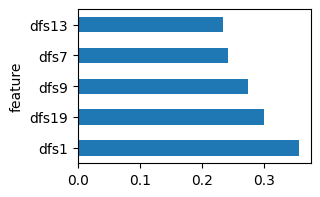

In [24]:
lr_importance_df.head().plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(3, 2),
    legend=False,
)
plt.show()

**DFS 13**: Please rate how much fear, anxiety, or unpleasantness for *seeing the dentist walk in*.  
**DFS 07**: When having dental work done *my heart beats faster*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  
**DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.  
**DFS 01**: Has fear of dental work every caused you to put off making an appointment.  

### shap importance

In [25]:
lr_explainer = shap.LinearExplainer(lr_model, X_train)
lr_shap_values = lr_explainer.shap_values(X_test)

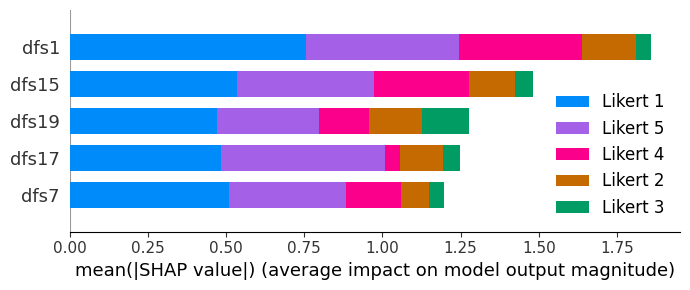

In [26]:
shap.summary_plot(
    lr_shap_values, 
    X_test, 
    plot_type='bar', 
    max_display=5, 
    plot_size=(7, 3),
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 01**: Has fear of dental work every caused you to put off making an appointment.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 07**: When having dental work done *my heart beats faster*.  

### Interpreting the SHAP Summary Plot

This bar plot shows **global feature importance** for the multiclass model that predicts `dfs20`. For each feature, the bar length is the **mean absolute SHAP value**: how much, on average, that feature shifts the model's output (in log-odds), regardless of direction. Each bar is broken into colored segments, one per response level of `dfs20`, so the total length is the feature's importance summed across all five classes. Features are sorted from most to least important overall, and only the top five are shown.

**Note:** this plot shows *magnitude only*. It does not show whether high agreement with a feature makes a given response more or less likely. Per-class beeswarm plots are needed for direction.

#### Approximate contributions

| Feature | Total | Likert 1 | Likert 5 | Likert 4 | Likert 2 | Likert 3 |
|:---|:---:|:---:|:---:|:---:|:---:|:---:|
| dfs1  | ~1.86 | 0.76 | 0.49 | 0.39 | 0.17 | 0.05 |
| dfs15 | ~1.48 | 0.54 | 0.43 | 0.31 | 0.15 | 0.05 |
| dfs19 | ~1.28 | 0.47 | 0.32 | 0.16 | 0.17 | 0.15 |
| dfs17 | ~1.25 | 0.48 | 0.53 | 0.05 | 0.14 | 0.05 |
| dfs7  | ~1.20 | 0.51 | 0.37 | 0.18 | 0.09 | 0.05 |

#### Key observations

**1. dfs1 is the most influential predictor**, followed by dfs15. Together with dfs17, these features were also among the top predictors in the non-stratified model, which suggests their importance is robust. dfs19 and dfs7 replaced dfs11 and dfs13 in the top five after stratification, so the ranking of the lower features is less stable.

**2. Most attribution goes to the extreme responses.**
Likert 1 has the largest segment for every feature, and Likert 5 is usually second. Because response 1 is very rare, its large SHAP values most likely reflect the model consistently pushing predictions *away* from that class, not identifying it. The attributions for Likert 5 are more meaningful: they show which items separate the most positive respondents from the rest.

**3. The middle responses receive little attribution.**
Likert 2 and especially Likert 3 have small segments. Low attribution does not necessarily mean poor prediction: in a multiclass (softmax) model, a middle response can be predicted because the scores for the other responses are pushed down. The confusion matrix shows that responses 2 and 3 are in fact predicted reasonably well.

**4. Features differ in which responses they inform.**
- **dfs17** contributes more to Likert 5 (0.53) than any other feature, but almost nothing to Likert 4 (0.05). It helps identify the most positive respondents but does not separate responses 4 and 5 from the middle.
- **dfs19** has the most even profile and is the only feature with a noticeable contribution to Likert 3 (0.15). It is the most informative item for the neutral response.
- **dfs1 and dfs15** contribute substantially to Likert 4 (0.39 and 0.31), so they are the main features distinguishing the upper-middle response.

#### Summary

A small set of items (dfs1, dfs15, dfs17) consistently drives the model's predictions, mostly by separating respondents at the ends of the scale. Attribution for the middle responses is spread thinly across features, which matches the confusion matrix, where most errors occur between adjacent response levels.

---

## LogisticAT

In [27]:
lrat_param_dist = {
    'alpha': loguniform(0.001, 100),  # regularization strength (NOT inverse like C), log scale
    'max_iter': [1000, 5000],
}

In [28]:
lrat_search = RandomizedSearchCV(
    estimator=LogisticAT(),
    param_distributions=lrat_param_dist,
    n_iter=20,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [29]:
# LogisticAT has no class_weight; pass balanced sample weights to mimic class_weight='balanced'
lrat_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
lrat_search.fit(X_train, y_train, sample_weight=lrat_sample_weight)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticAT()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': <scipy.stats....t 0x12892fa10>, 'max_iter': [1000, 5000]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the

In [30]:
lrat_model = lrat_search.best_estimator_

In [31]:
lrat_best_score = lrat_search.best_score_
lrat_best_params = lrat_search.best_params_

In [32]:
print("Best LRAT balanced_accuracy score:", lrat_best_score) # 0.55 – 0.70 is a moderate score
print("Best LRAT params:", lrat_best_params)

Best LRAT balanced_accuracy score: 0.60749564710218
Best LRAT params: {'alpha': np.float64(73.92266140516048), 'max_iter': 1000}


In [33]:
y_pred = lrat_model.predict(X_test)

In [34]:
y_pred = lrat_model.predict(X_test)

### classification report

In [35]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.90      0.77      0.83       684
           2       0.51      0.60      0.55       331
           3       0.40      0.45      0.43       174
           4       0.32      0.45      0.37       100
           5       0.72      0.54      0.62       114

    accuracy                           0.65      1403
   macro avg       0.57      0.56      0.56      1403
weighted avg       0.69      0.65      0.66      1403



In [36]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.65
Macro F1:              0.56
Weighted F1:           0.66
Micro F1:              0.65
Within ±1 accuracy:    0.97
Quadratic weighted κ:  0.85


### confusion matrix

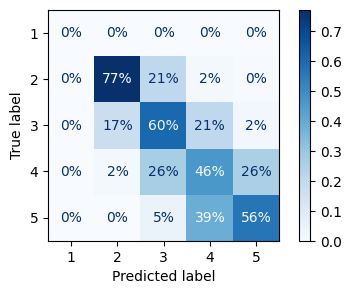

In [37]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance based on coeficients

In [38]:
lrat_coef = lrat_search.best_estimator_.coef_
lrat_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': lrat_coef,
    'importance': np.abs(lrat_coef),
}).sort_values('importance', ascending=False)

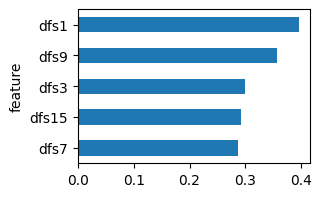

In [39]:
lrat_importance_df.head().plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(3, 2),
    legend=False,
)
plt.gca().invert_yaxis()  # most important at the top
plt.show()

**DFS 01**: Has fear of dental work every caused you to put off making an appointment?   
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  
**DFS 03**: When having dental work done *my muscles become tense*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 07**: When having dental work done *my heart beats faster*.  

### shap importance

In [40]:
# lrat_masker tells SHAP what to substitute for a feature when it measures what happens without that feature.
lrat_masker = shap.maskers.Independent(X_train, max_samples=100)

In [41]:
def lrat_latent(X):
    return np.asarray(X) @ lrat_model.coef_

### Explaining the Ordinal Model with SHAP: the Latent Score

```python
def lrat_latent(X):
    return np.asarray(X) @ lrat_model.coef_
```

This function gives SHAP the part of the `LogisticAT` model that depends on the features.

#### How `LogisticAT` makes predictions

The all-threshold ordinal logistic model predicts in two steps:

1. **Latent score.** It combines the item responses into a single number for each respondent:

   $$\eta = w_1 \cdot \text{dfs1} + w_2 \cdot \text{dfs2} + \dots + w_p \cdot \text{dfs}_p$$

   where the weights $w_j$ are stored in `lrat_model.coef_`.

2. **Thresholds.** It compares $\eta$ with a set of ordered cutpoints $\theta_1 < \theta_2 < \theta_3 < \theta_4$ (stored in `lrat_model.theta_`) that divide the latent scale into the five response levels:

   $$P(\text{dfs20} \le k) = \sigma(\theta_k - \eta)$$

   where $\sigma$ is the logistic function. A higher $\eta$ lowers the probability of falling at or below each cutpoint, so the predicted response moves up the scale. Roughly, the predicted response is the number of thresholds that $\eta$ has passed.

The model has no separate intercept; its role is absorbed into the thresholds.

#### What the function does

- `np.asarray(X)` converts the input to a NumPy array. SHAP's masker may pass either a DataFrame or an array.
- `@ lrat_model.coef_` multiplies the $(n \times p)$ feature matrix by the $p$ coefficients, returning one latent score $\eta$ per respondent, with shape $(n,)$.

SHAP needs a function that maps a batch of feature rows to one output per row, and this provides it.

#### Why explain the latent score?

- **The thresholds are constants.** They are the same for every respondent, so they cannot account for differences between respondents. All variation between respondents comes from $\eta$.
- **The direction is consistent.** Because a higher $\eta$ always means a higher predicted response, a positive SHAP value always pushes a respondent toward higher `dfs20` responses and a negative value toward lower ones. Each feature gets a single explanation instead of five class-specific ones.
- **The values are exact and simple.** Because $\eta$ is linear, the SHAP value of feature $j$ for a respondent is

  $$\phi_j = w_j \, (x_j - \bar{x}_j)$$

  that is, how far the respondent's answer is from the background mean, times the item's weight.

  *Example:* if $w_{\text{dfs1}} = 0.8$, the background mean of dfs1 is 2.5, and a respondent answered 4, then dfs1's SHAP value for that respondent is $0.8 \times (4 - 2.5) = +1.2$.

#### Interpreting the values

SHAP values are in **latent units**, not probabilities. The spacing of the thresholds gives them a scale: if adjacent cutpoints are about 1.5 units apart, a SHAP value of $+1.2$ moves a respondent most of the way from one response level to the next. Because the units differ, the bar lengths in this plot are not directly comparable with those of the multiclass model, which are in per-class log-odds. Compare the models by the **ranking and direction** of features.?

In [42]:
lrat_explainer = shap.Explainer(
    lrat_latent, lrat_masker,
    feature_names=X_train.columns.tolist(),
)
lrat_shap_values = lrat_explainer(X_test)

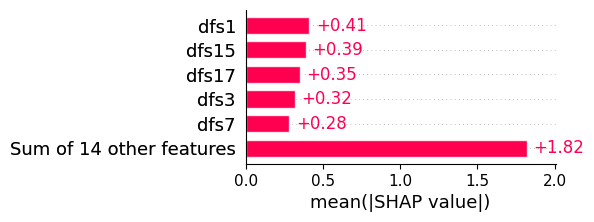

In [43]:
fig, ax = plt.subplots(figsize=(4, 2))
shap.plots.bar(lrat_shap_values, max_display=6, ax=ax, show=False)
plt.show()

**DFS 01**: Has fear of dental work every caused you to put off making an appointment?    
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 03**: When having dental work done *my muscles become tense*.  
**DFS 07**: When having dental work done *my heart beats faster*.  

---

## LightGBM

In [44]:
lgbm_param_dist = {
    'n_estimators': randint(100, 1000),
    'learning_rate': loguniform(0.005, 0.2),
    'num_leaves': randint(4, 32),            # main complexity control; keep small for survey-sized data
    'max_depth': [-1, 3, 4, 5, 6],
    'min_child_samples': randint(5, 50),     # min respondents per leaf
    'subsample': uniform(0.6, 0.4),          # 0.6–1.0, row bagging
    'subsample_freq': [1],                   # needed for subsample to take effect
    'colsample_bytree': uniform(0.5, 0.5),   # 0.5–1.0, feature bagging
    'reg_alpha': loguniform(1e-3, 10),       # L1
    'reg_lambda': loguniform(1e-3, 10),      # L2
}

In [45]:
lgbm_search = RandomizedSearchCV(
    estimator=lgb.LGBMClassifier(
        objective='multiclass',
        class_weight='balanced',
        random_state=42,
        n_jobs=1,        # let the search parallelize across fits instead
        verbose=-1,      # silence LightGBM's per-fit logging
    ),
    param_distributions=lgbm_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [46]:
lgbm_search.fit(X_train, y_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","LGBMClassifie...2, verbose=-1)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x12a531a50>, 'learning_rate': <scipy.stats....t 0x128aa0b10>, 'max_depth': [-1, 3, ...], 'min_child_samples': <scipy.stats....t 0x129a50c90>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations o

In [47]:
lgbm_model = lgbm_search.best_estimator_

In [48]:
lgbm_best_score = lgbm_search.best_score_
lgbm_best_params = lgbm_search.best_params_

In [49]:
print("Best LGB score:", lgbm_best_score)
print("Best LGB params:", lgbm_best_params)

Best LGB score: 0.6223056366924161
Best LGB params: {'colsample_bytree': np.float64(0.5324461235544908), 'learning_rate': np.float64(0.01275726949987024), 'max_depth': 5, 'min_child_samples': 43, 'n_estimators': 485, 'num_leaves': 6, 'reg_alpha': np.float64(0.015977662354833867), 'reg_lambda': np.float64(0.013783578294796388), 'subsample': np.float64(0.6147547789418131), 'subsample_freq': 1}


In [50]:
lgbm_model.fit(X_train, y_train)

,num_leaves,6
,max_depth,5
,learning_rate,np.float64(0....5726949987024)
,n_estimators,485
,objective,'multiclass'
,class_weight,'balanced'
,min_child_samples,43
,subsample,np.float64(0.6147547789418131)
,subsample_freq,1
,colsample_bytree,np.float64(0.5324461235544908)
,reg_alpha,np.float64(0....7662354833867)


In [51]:
y_pred = lgbm_model.predict(X_test)

### classification reprort

In [52]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.90      0.79      0.84       684
           2       0.54      0.60      0.57       331
           3       0.41      0.48      0.44       174
           4       0.39      0.48      0.43       100
           5       0.69      0.62      0.65       114

    accuracy                           0.67      1403
   macro avg       0.59      0.60      0.59      1403
weighted avg       0.70      0.67      0.68      1403



In [53]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.67
Macro F1:              0.59
Weighted F1:           0.68
Micro F1:              0.67
Within ±1 accuracy:    0.96
Quadratic weighted κ:  0.84


### confusion matrix

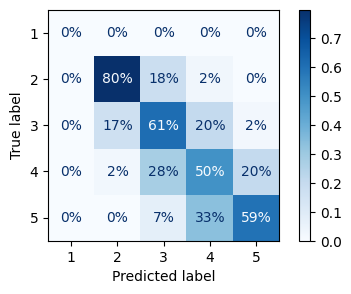

In [54]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance based on coeficients¶

In [55]:
lgbm_importances = pd.Series(lgbm_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)

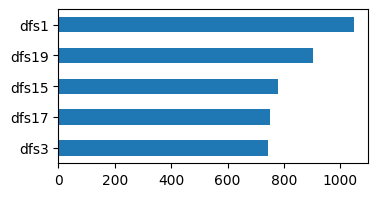

In [56]:
lgbm_importances.tail().plot(kind='barh', figsize=(4, 2))
plt.show()

**DFS 01**: Has fear of dental work every caused you to put off making an appointment?    
**DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 03**: When having dental work done *my muscles become tense*.  

### shap importances

In [57]:
lgbm_explainer = shap.TreeExplainer(lgbm_model)
lgbm_shap_values = lgbm_explainer(X_test)

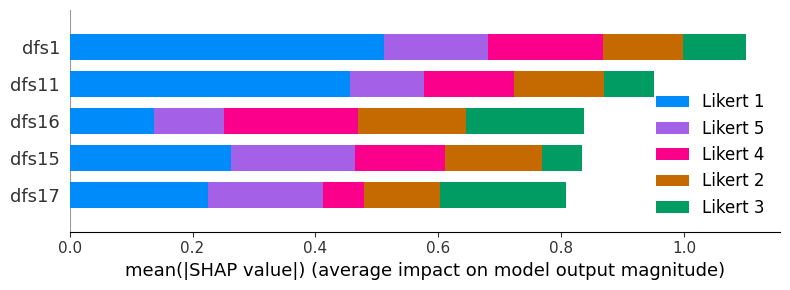

In [58]:
shap.summary_plot(
    lgbm_shap_values, 
    X_test, plot_type='bar',
    max_display=5, 
    plot_size=(8, 3), 
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 01**: Has fear of dental work every caused you to put off making an appointment?    
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  

---

## GradientBoostingClassifier

In [59]:
gbc_param_dist = {
    'n_estimators': randint(100, 500),
    'learning_rate': loguniform(0.01, 0.2),
    'max_depth': randint(2, 6),              # shallow trees; main complexity control
    'min_samples_leaf': randint(5, 50),      # min respondents per leaf
    'min_samples_split': randint(10, 100),
    'subsample': uniform(0.6, 0.4),          # 0.6–1.0; <1.0 = stochastic gradient boosting
    'max_features': ['sqrt', 'log2', None],
}

In [60]:
gbc_search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gbc_param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [61]:
# GradientBoostingClassifier has no class_weight; balanced sample weights mimic it
gbc_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train)
gbc_search.fit(X_train, y_train, sample_weight=gbc_sample_weight)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'learning_rate': <scipy.stats....t 0x12b4656d0>, 'max_depth': <scipy.stats....t 0x12a6c4490>, 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....t 0x12a7a4190>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations

In [62]:
gbc_model = gbc_search.best_estimator_

In [63]:
gbc_best_score = gbc_search.best_score_
gbc_best_params = gbc_search.best_params_

In [64]:
print("Best GBC score:", gbc_best_score)
print("Best GBC params:", gbc_best_params)

Best GBC score: 0.6256935174149029
Best GBC params: {'learning_rate': np.float64(0.030710573677773714), 'max_depth': 2, 'max_features': None, 'min_samples_leaf': 47, 'min_samples_split': 81, 'n_estimators': 288, 'subsample': np.float64(0.8387400631785948)}


In [65]:
y_pred = gbc_model.predict(X_test)

### classification reprort

In [66]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.89      0.78      0.83       684
           2       0.53      0.57      0.55       331
           3       0.38      0.48      0.43       174
           4       0.36      0.43      0.39       100
           5       0.63      0.59      0.61       114

    accuracy                           0.65      1403
   macro avg       0.56      0.57      0.56      1403
weighted avg       0.68      0.65      0.67      1403



In [67]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.65
Macro F1:              0.56
Weighted F1:           0.67
Micro F1:              0.65
Within ±1 accuracy:    0.95
Quadratic weighted κ:  0.83


### confusion matrix

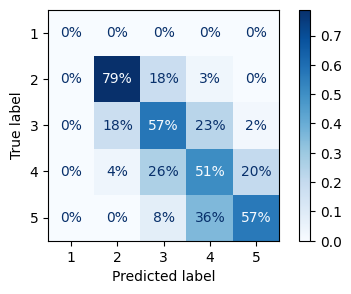

In [68]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance  

In [69]:
gbc_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': gbc_model.feature_importances_,
}).sort_values('importance', ascending=False)

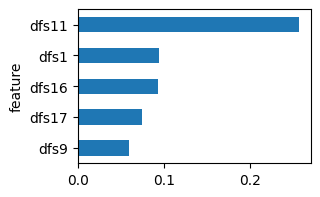

In [70]:
gbc_importance_df.head().plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(3, 2),
    legend=False,
)
plt.gca().invert_yaxis()
plt.show()

**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 01**: Has fear of dental work every caused you to put off making an appointment?  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  

## shap importance  
GradientBoostingClassifier is only supported for binary classification right now. For your five-class model, use the model-agnostic explainer on the model's raw class scores.

In [71]:
gbc_masker = shap.maskers.Independent(X_train, max_samples=100)

In [72]:
def gbc_raw_scores(X):
    # rebuild a DataFrame so sklearn doesn't warn about missing feature names
    X = pd.DataFrame(np.asarray(X), columns=X_train.columns)
    return gbc_model.decision_function(X)   # shape (n, 5): raw per-class scores

In [73]:
gbc_explainer = shap.Explainer(
    gbc_raw_scores, gbc_masker,
    feature_names=X_train.columns.tolist(),
    output_names=[f"Likert {k + 1}" for k in range(5)],
)
gbc_shap_values = gbc_explainer(X_test)   # shape (n, features, 5)

PermutationExplainer explainer: 1404it [04:10,  5.39it/s]                                                               


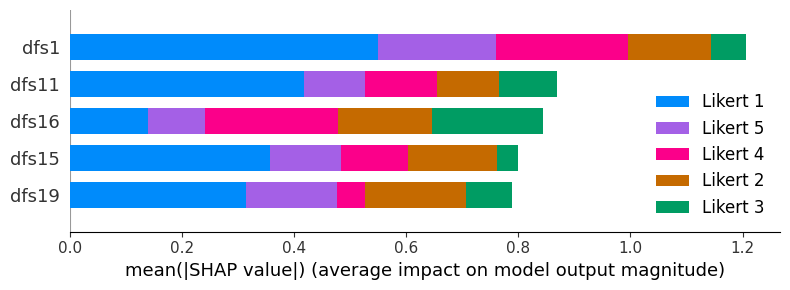

In [74]:
shap.summary_plot(
    gbc_shap_values, 
    X_test, 
    plot_type='bar', 
    max_display=5, plot_size=(8, 3),
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 01**: Has fear of dental work every caused you to put off making an appointment?  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.  

----

## BalancedRandomForest

In [75]:
brf_param_dist = {
    'n_estimators': randint(100, 800),
    'max_depth': [None, 4, 6, 8, 12],
    'min_samples_leaf': randint(1, 20),
    'min_samples_split': randint(2, 30),
    'max_features': ['sqrt', 'log2', 0.5],
    'sampling_strategy': ['all', 'not minority'],
}

In [76]:
brf_search = RandomizedSearchCV(
    estimator=BalancedRandomForestClassifier(
        replacement=True,
        bootstrap=False,     # set explicitly: imblearn's defaults changed in 0.13
        random_state=42,
        n_jobs=1,
    ),
    param_distributions=brf_param_dist,
    n_iter=30,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [77]:
brf_search.fit(X_train, y_train)

Fitting 3 folds for each of 30 candidates, totalling 90 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",BalancedRando...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 4, ...], 'max_features': ['sqrt', 'log2', ...], 'min_samples_leaf': <scipy.stats....t 0x12b750a50>, 'min_samples_split': <scipy.stats....t 0x12b710ad0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than 

In [78]:
brf_model = brf_search.best_estimator_

In [79]:
brf_best_score = brf_search.best_score_
brf_best_params = brf_search.best_params_

In [80]:
print("Best BRF score:", brf_best_score)
print("Best BRF params:", brf_best_params)

Best BRF score: 0.62394509343273
Best BRF params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 6, 'n_estimators': 506, 'sampling_strategy': 'all'}


In [81]:
y_pred = brf_model.predict(X_test)

### classification reprort

In [82]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.91      0.78      0.84       684
           2       0.51      0.63      0.57       331
           3       0.42      0.46      0.44       174
           4       0.39      0.47      0.43       100
           5       0.75      0.62      0.68       114

    accuracy                           0.67      1403
   macro avg       0.60      0.59      0.59      1403
weighted avg       0.70      0.67      0.68      1403



In [83]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.67
Macro F1:              0.59
Weighted F1:           0.68
Micro F1:              0.67
Within ±1 accuracy:    0.96
Quadratic weighted κ:  0.84


### confusion matrix

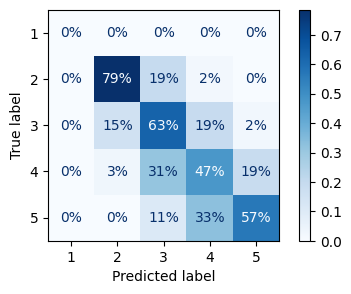

In [84]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance  
A random forest has no coefficients. The closest equivalent is feature_importances_, which measures how much each feature reduces impurity across all the trees. It is always non-negative and shows no direction

In [85]:
brf_importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': brf_model.feature_importances_,
}).sort_values('importance', ascending=False)

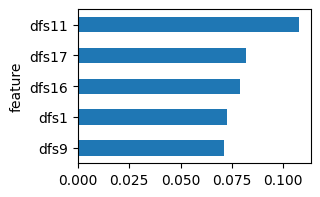

In [86]:
brf_importance_df.head().plot(
    kind='barh',
    x='feature',
    y='importance',
    figsize=(3, 2),
    legend=False,
)
plt.gca().invert_yaxis()
plt.show()

**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 01**: Has fear of dental work every caused you to put off making an appointment?  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  

### shap importances

In [87]:
brf_explainer = shap.TreeExplainer(brf_model)
brf_shap_values = brf_explainer(X_test)

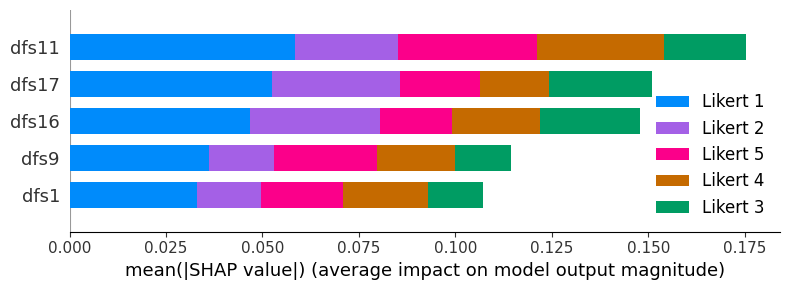

In [88]:
shap.summary_plot(
    brf_shap_values, 
    X_test, 
    plot_type='bar', 
    max_display=5, 
    plot_size=(8, 3),
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  
**DFS 01**: Has fear of dental work every caused you to put off making an appointment?   

---

## XGBoost

In [89]:
xgb_param_dist = {
    'n_estimators': randint(100, 1000),
    'learning_rate': loguniform(0.005, 0.2),
    'max_depth': randint(2, 7),
    'min_child_weight': loguniform(0.5, 20),   # min weighted respondents per leaf
    'subsample': uniform(0.6, 0.4),            # 0.6–1.0
    'colsample_bytree': uniform(0.5, 0.5),     # 0.5–1.0
    'gamma': loguniform(1e-3, 5),              # min loss reduction to split
    'reg_alpha': loguniform(1e-3, 10),         # L1
    'reg_lambda': loguniform(1e-3, 10),        # L2
}

In [90]:
xgb_search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(
        objective='multi:softprob',
        eval_metric='mlogloss',
        tree_method='hist',
        random_state=42,
        n_jobs=1,          # let the search parallelize across fits
    ),
    param_distributions=xgb_param_dist,
    n_iter=50,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='balanced_accuracy',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

In [91]:
# XGBoost requires class labels to be the consecutive integers 0 to K−1, and the other models don't. If you'd rather keep y as 1–5 for everything else, shift the labels for XGBoost alone:
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

In [92]:
# XGBoost has no class_weight; balanced sample weights mimic it
xgb_sample_weight = compute_sample_weight(class_weight='balanced', y=y_train_xgb)
xgb_search.fit(X_train, y_train_xgb, sample_weight=xgb_sample_weight)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': <scipy.stats....t 0x12a1a4f50>, 'gamma': <scipy.stats....t 0x129a60750>, 'learning_rate': <scipy.stats....t 0x12a29e0d0>, 'max_depth': <scipy.stats....t 0x129d8d8d0>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'balanced_accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default = 0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerat

In [93]:
xgb_model = xgb_search.best_estimator_

In [94]:
xgb_best_score = xgb_search.best_score_
xgb_best_params = xgb_search.best_params_

In [95]:
print("Best XGB score:", xgb_best_score)
print("Best XGB params:", xgb_best_params)

Best XGB score: 0.6199138040598363
Best XGB params: {'colsample_bytree': np.float64(0.6354161256310371), 'gamma': np.float64(0.042047687702178926), 'learning_rate': np.float64(0.006678237100523691), 'max_depth': 6, 'min_child_weight': np.float64(0.9869237699568577), 'n_estimators': 929, 'reg_alpha': np.float64(2.207600491318519), 'reg_lambda': np.float64(0.6079905434073399), 'subsample': np.float64(0.763581177765708)}


In [96]:
# Shift the predictions back so they're on the same 1–5 scale as the other models.
xgb_y_pred = xgb_model.predict(X_test) + 1
xgb_labels = np.unique(np.concatenate([np.asarray(y_test), xgb_y_pred]))

## classification report

In [97]:
print(classification_report(y_test, xgb_y_pred, labels=xgb_labels))

              precision    recall  f1-score   support

           1       0.90      0.79      0.84       684
           2       0.52      0.61      0.57       331
           3       0.45      0.51      0.48       174
           4       0.39      0.46      0.42       100
           5       0.67      0.60      0.63       114

    accuracy                           0.67      1403
   macro avg       0.59      0.59      0.59      1403
weighted avg       0.70      0.67      0.68      1403



In [98]:
print(f"Exact accuracy:        {accuracy_score(y_test, y_pred):.2f}")
print(f"Macro F1:              {f1_score(y_test, y_pred, average='macro', zero_division=0):.2f}")
print(f"Weighted F1:           {f1_score(y_test, y_pred, average='weighted', zero_division=0):.2f}")
print(f"Micro F1:              {f1_score(y_test, y_pred, average='micro'):.2f}")
print(f"Within ±1 accuracy:    {np.mean(np.abs(np.asarray(y_test) - np.asarray(y_pred)) <= 1):.2f}")
print(f"Quadratic weighted κ:  {cohen_kappa_score(y_test, y_pred, weights='quadratic'):.2f}")

Exact accuracy:        0.67
Macro F1:              0.59
Weighted F1:           0.68
Micro F1:              0.67
Within ±1 accuracy:    0.96
Quadratic weighted κ:  0.84


### confusion matrix

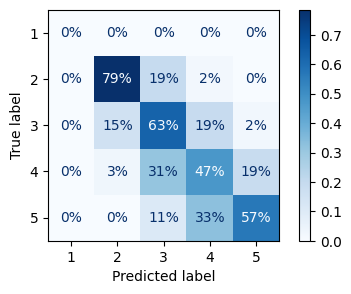

In [99]:
fig, ax = plt.subplots(figsize=(5, 3))   # width, height in inches
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    labels=[0, 1, 2, 3, 4],
    display_labels=["1", "2", "3", "4", "5"],  # Likert responses
    normalize="true",        # row-normalize (recall); None for raw counts
    values_format=".0%",     # use "d" when normalize=None
    cmap="Blues",
    ax=ax,
    colorbar=True,
)
plt.show()

### feature importance

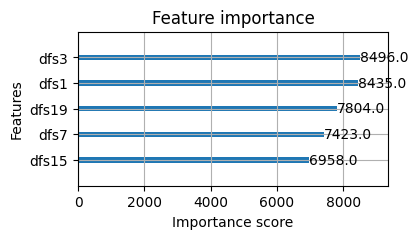

In [100]:
# Plot importance using default weight/gain
fig, ax = plt.subplots(figsize=(4, 2))
xgb.plot_importance(xgb_model, ax=ax, max_num_features=5)
plt.show()

**DFS 03**: When having dental work done *my muscles become tense*.  
**DFS 01**: Has fear of dental work every caused you to put off making an appointment?  
**DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.  
**DFS 07**: When having dental work done *my heart beats faster*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  

### shap importances

In [101]:
xgb_explainer = shap.TreeExplainer(xgb_model)
xgb_shap_values = xgb_explainer(X_test)   # shape (n, features, 5), per-class log-odds

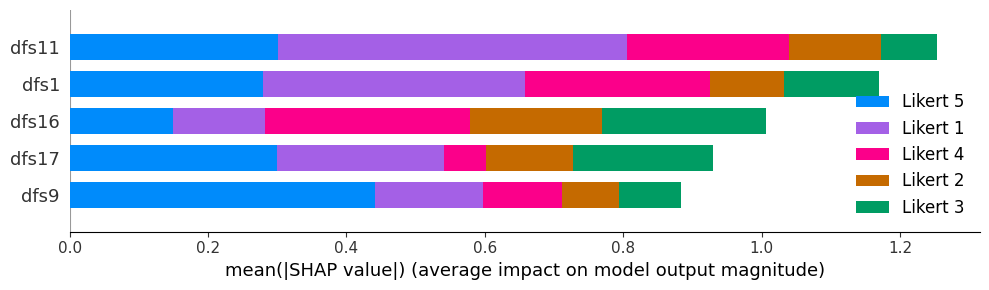

In [102]:
shap.summary_plot(
    xgb_shap_values, 
    X_test, 
    plot_type='bar', 
    max_display=5, 
    plot_size=(10, 3),
    class_names=['Likert 1', 'Likert 2', 'Likert 3', 'Likert 4', 'Likert 5']
)

**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 01**: Has fear of dental work every caused you to put off making an appointment?   
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  

---

## Compare and Visualize Results

In [103]:
from lib.superdataset_utils import (
    shap_ranking, 
    native_ranking, 
    rank_feature_counts_long, 
    compare_top_n_counts, 
    plot_top_n_counts, 
    build_feature_color_map, 
    style_rank_table,
    rank_position_counts,
    top_n_feature_counts,
    rank_feature_counts_long,
    bar_plot_rank_composition,
    plot_rank_heatmap,
    plot_rank_heatmaps_side_by_side,
    build_model_annotations,
    align_rank_counts
)   

In [104]:
# dict of model abbreviations
model_abbrev = {
    "LogisticRegression": "LR",
    "LogisticAT": "LRAT",
    "LightGBM": "LGB",
    "GradientBoostingClassifier": "GBC",
    "BalancedRandomForest": "BRF",
    "XGBoost": "XGB"
}

In [105]:
# For each model, get features sorted by importance (most important first)
shap_rankings = {
    'LogisticRegression':         shap_ranking(lr_shap_values,   X_test.columns),
    'LogisticAT':                 shap_ranking(lrat_shap_values, X_test.columns),
    'LightGBM':                   shap_ranking(lgbm_shap_values, X_test.columns),
    'GradientBoostingClassifier': shap_ranking(gbc_shap_values,  X_test.columns),
    'BalancedRandomForest':       shap_ranking(brf_shap_values,  X_test.columns),
    'XGBoost':                    shap_ranking(xgb_shap_values,  X_test.columns),
}

In [106]:
# Build a table: rows = rank (1st, 2nd, 3rd...), columns = model
shap_rank_df = pd.DataFrame(shap_rankings)
shap_rank_df.index = shap_rank_df.index + 1
shap_rank_df.index.name = 'Rank'
shap_rank_df.head()

,LogisticRegression,LogisticAT,LightGBM,GradientBoostingClassifier,BalancedRandomForest,XGBoost
Rank,,,,,,
1,dfs1,dfs1,dfs1,dfs1,dfs11,dfs11
2,dfs15,dfs15,dfs11,dfs11,dfs17,dfs1
3,dfs19,dfs17,dfs16,dfs16,dfs16,dfs16
4,dfs17,dfs3,dfs15,dfs15,dfs9,dfs17
5,dfs7,dfs7,dfs17,dfs19,dfs1,dfs9


### compare Native Feature Importances (e.g., coeficients)

In [107]:
native_rankings = {
    'LogisticRegression':         native_ranking(lr_model.coef_, X_train.columns),     # mean |coef| across classes
    'LogisticAT':                 native_ranking(lrat_model.coef_, X_train.columns),   # single shared coef vector
    'LightGBM':                   native_ranking(lgbm_model.booster_.feature_importance(importance_type='gain'), X_train.columns),
    'GradientBoostingClassifier': native_ranking(gbc_model.feature_importances_, X_train.columns),  # impurity-based
    'BalancedRandomForest':       native_ranking(brf_model.feature_importances_, X_train.columns),  # impurity-based
    'XGBoost':                    native_ranking(xgb_model.feature_importances_, X_train.columns),  # gain by default
}

In [108]:
native_rank_df = pd.DataFrame(native_rankings)
native_rank_df.index = native_rank_df.index + 1
native_rank_df.index.name = 'Rank'
native_rank_df.head()

,LogisticRegression,LogisticAT,LightGBM,GradientBoostingClassifier,BalancedRandomForest,XGBoost
Rank,,,,,,
1,dfs1,dfs1,dfs11,dfs11,dfs11,dfs11
2,dfs19,dfs9,dfs1,dfs1,dfs17,dfs16
3,dfs9,dfs3,dfs17,dfs16,dfs16,dfs9
4,dfs7,dfs15,dfs16,dfs17,dfs1,dfs17
5,dfs13,dfs7,dfs9,dfs9,dfs9,dfs13


In [109]:
native_value_counts = pd.Series(native_rank_df.head(3).values.ravel()).value_counts()
native_value_counts

dfs1     4
dfs11    4
dfs9     3
dfs16    3
dfs17    2
dfs19    1
dfs3     1
Name: count, dtype: int64

In [110]:
# uncomment to see table with columns "Rank, Feature, Count, Models"
# rank_feature_counts_long(native_rank_df, top_n=5, include_models=True)

In [111]:
# uncomment to native vs shap counts
# comparison = compare_top_n_counts(native_rank_df, shap_rank_df, top_n=5, names=('native', 'shap'))
# comparison

### visualizations

In [112]:
feature_color_map = build_feature_color_map(native_rank_df, shap_rank_df, softness=0.7)

In [113]:
style_rank_table(shap_rank_df.head(), feature_color_map)

,LogisticRegression,LogisticAT,LightGBM,GradientBoostingClassifier,BalancedRandomForest,XGBoost
Rank,,,,,,
1,dfs1,dfs1,dfs1,dfs1,dfs11,dfs11
2,dfs15,dfs15,dfs11,dfs11,dfs17,dfs1
3,dfs19,dfs17,dfs16,dfs16,dfs16,dfs16
4,dfs17,dfs3,dfs15,dfs15,dfs9,dfs17
5,dfs7,dfs7,dfs17,dfs19,dfs1,dfs9


In [114]:
style_rank_table(native_rank_df.head(), feature_color_map)

,LogisticRegression,LogisticAT,LightGBM,GradientBoostingClassifier,BalancedRandomForest,XGBoost
Rank,,,,,,
1,dfs1,dfs1,dfs11,dfs11,dfs11,dfs11
2,dfs19,dfs9,dfs1,dfs1,dfs17,dfs16
3,dfs9,dfs3,dfs17,dfs16,dfs16,dfs9
4,dfs7,dfs15,dfs16,dfs17,dfs1,dfs17
5,dfs13,dfs7,dfs9,dfs9,dfs9,dfs13


In [115]:
# rank_position_counts(native_rank_df)  

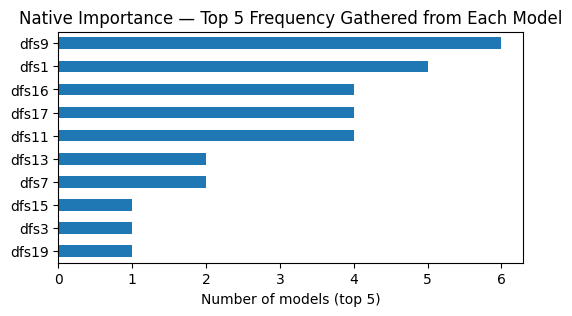

In [116]:
native_top5 = top_n_feature_counts(native_rank_df, top_n=5)
plot_top_n_counts(native_top5, top_n=5, title='Native Importance — Top 5 Frequency Gathered from Each Model')

**DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  
**DFS 01**: Has fear of dental work every caused you to put off making an appointment?  
**DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.  
**DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.  
**DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
**DFS 13**: Please rate how much fear, anxiety, or unpleasantness for *seeing the dentist walk in*.  
**DFS 07**: When having dental work done *my heart beats faster*.  
**DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
**DFS 03**: When having dental work done *my muscles become tense*.  
**DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.  

## native rankings

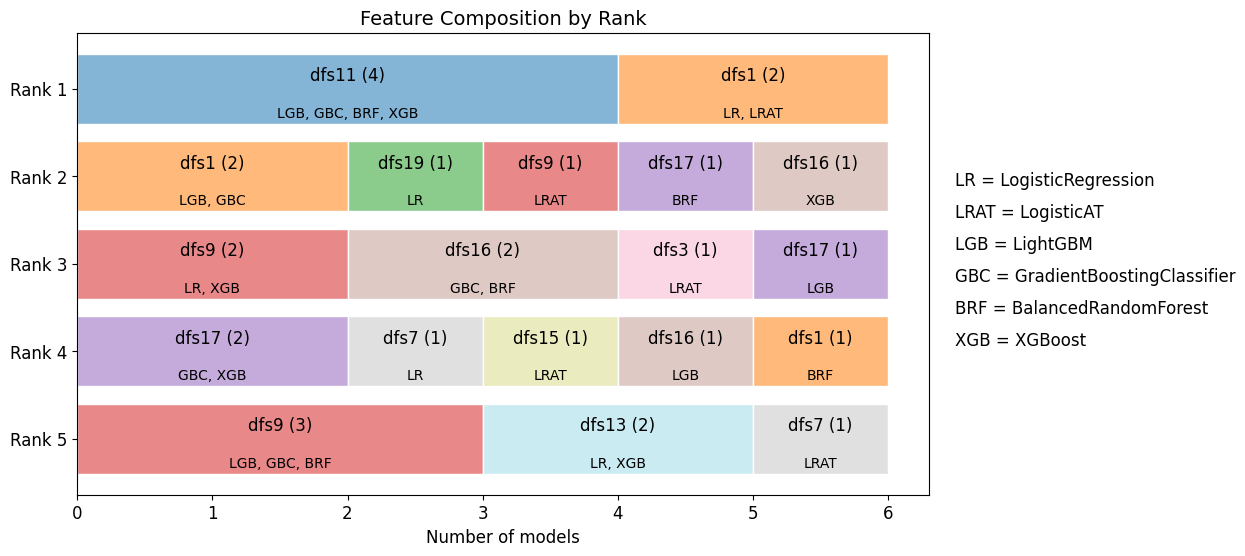

In [117]:
native_long = rank_feature_counts_long(native_rank_df, top_n=5, include_models=True)
bar_plot_rank_composition(native_long, figsize=(13, 6), model_abbrev=model_abbrev, legend_loc='right', wrap_width=30, fontsize=12)

**Rank 1**  
* **DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.
* **DFS 01**: Has fear of dental work every caused you to put off making an appointment?

**Rank 2**  
* **DFS 01**: Has fear of dental work every caused you to put off making an appointment?
* **DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.
* **DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.
* **DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.
* **DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.

**Rank 3**  
* **DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.
* **DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.
* **DFS 03**: When having dental work done *my muscles become tense*.  
* **DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.

**Rank 4**  
* **DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.
* **DFS 07**: When having dental work done *my heart beats faster*.
* **DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
* **DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.
* **DFS 01**: Has fear of dental work every caused you to put off making an appointment?  

**Rank 5**  
* **DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.
* **DFS 13**: Please rate how much fear, anxiety, or unpleasantness for *seeing the dentist walk in*.
* **DFS 07**: When having dental work done *my heart beats faster*.  

## shap rankings

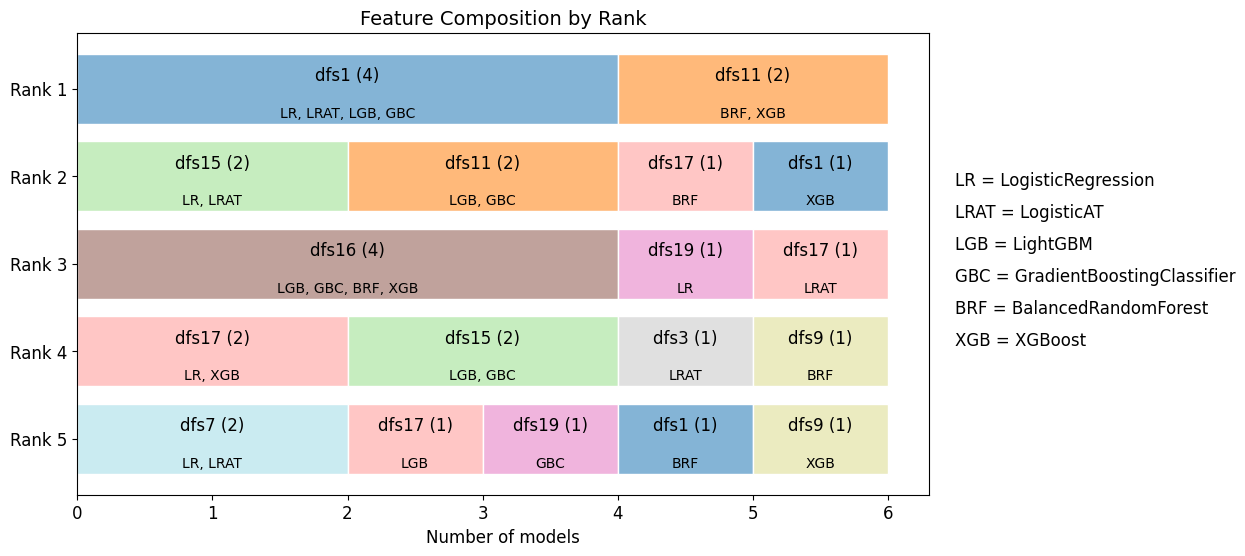

In [118]:
shap_long = rank_feature_counts_long(shap_rank_df, top_n=5, include_models=True)
bar_plot_rank_composition(shap_long, figsize=(13, 6), model_abbrev=model_abbrev, legend_loc='right', wrap_width=30, fontsize=12)

**Rank 1**  
* **DFS 01**: Has fear of dental work every caused you to put off making an appointment?
* **DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.

**Rank 2**  
* **DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.
* **DFS 11**: Please rate how much fear, anxiety, or unpleasantness for *being seated in the dental chair*.  
* **DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.
* **DFS 01**: Has fear of dental work every caused you to put off making an appointment?

**Rank 3**  
* **DFS 16**: Please rate how much fear, anxiety, or unpleasantness for *seeing the drill*.
* **DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.  
* **DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.

**Rank 4**  
* **DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.
* **DFS 15**: Please rate how much fear, anxiety, or unpleasantness for *feeling the needle injected*.  
* **DFS 03**: When having dental work done *my muscles become tense*.  
* **DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.

**Rank 5**  
* **DFS 07**: When having dental work done *my heart beats faster*.  
* **DFS 17**: Please rate how much fear, anxiety, or unpleasantness for *hearing the drill*.
* **DFS 19**: Please rate how much fear, anxiety, or unpleasantness for *having your teeth cleaned*.
* **DFS 01**: Has fear of dental work every caused you to put off making an appointment?
* **DFS 09**: Please rate how much fear, anxiety, or unpleasantness for *approaching the dentist's office*.  

## experimenting with heat maps

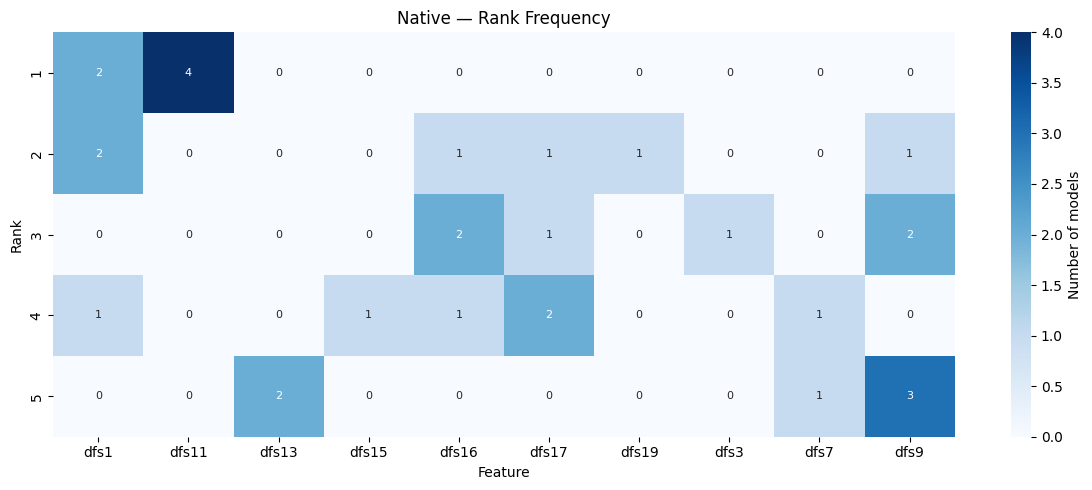

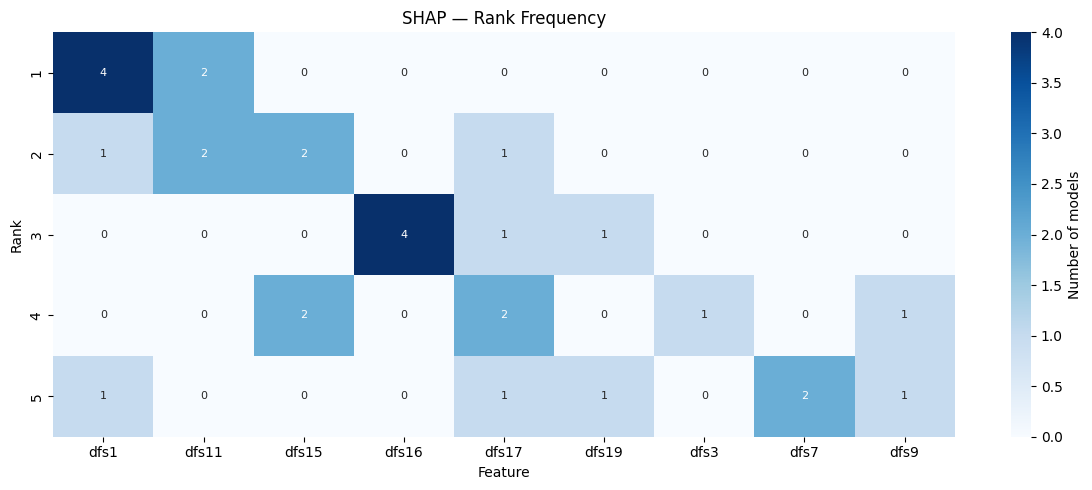

In [119]:
plot_rank_heatmap(rank_position_counts(native_rank_df, top_n=5), title='Native — Rank Frequency')
plot_rank_heatmap(rank_position_counts(shap_rank_df, top_n=5), title='SHAP — Rank Frequency')

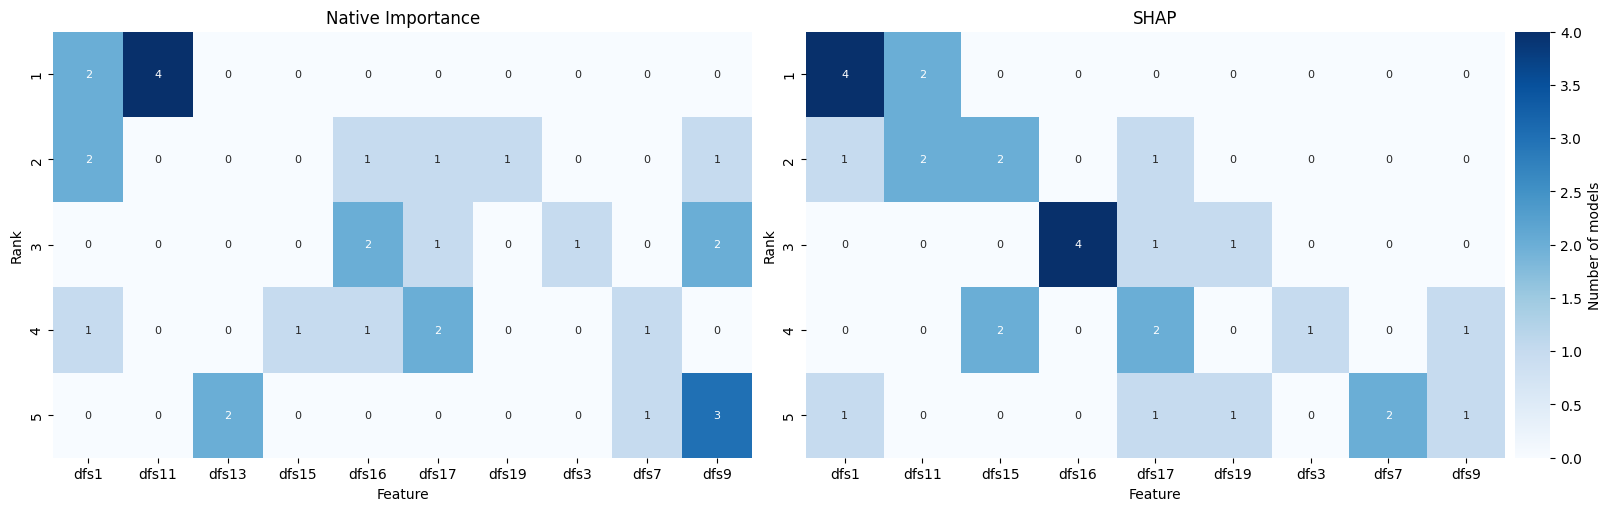

In [120]:
native_counts = rank_position_counts(native_rank_df, top_n=5)
shap_counts = rank_position_counts(shap_rank_df, top_n=5)

plot_rank_heatmaps_side_by_side(
    [native_counts, shap_counts],
    titles=['Native Importance', 'SHAP'],
)

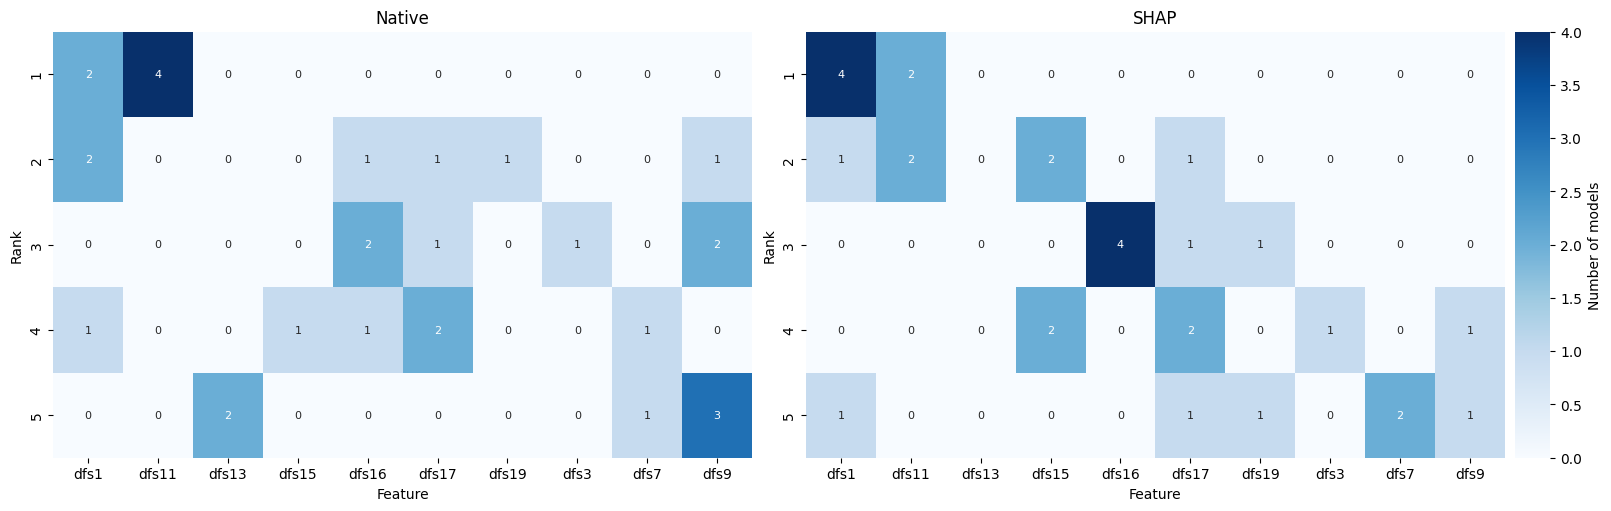

In [121]:
native_counts, shap_counts = align_rank_counts(native_counts, shap_counts)
plot_rank_heatmaps_side_by_side([native_counts, shap_counts], titles=['Native', 'SHAP'])

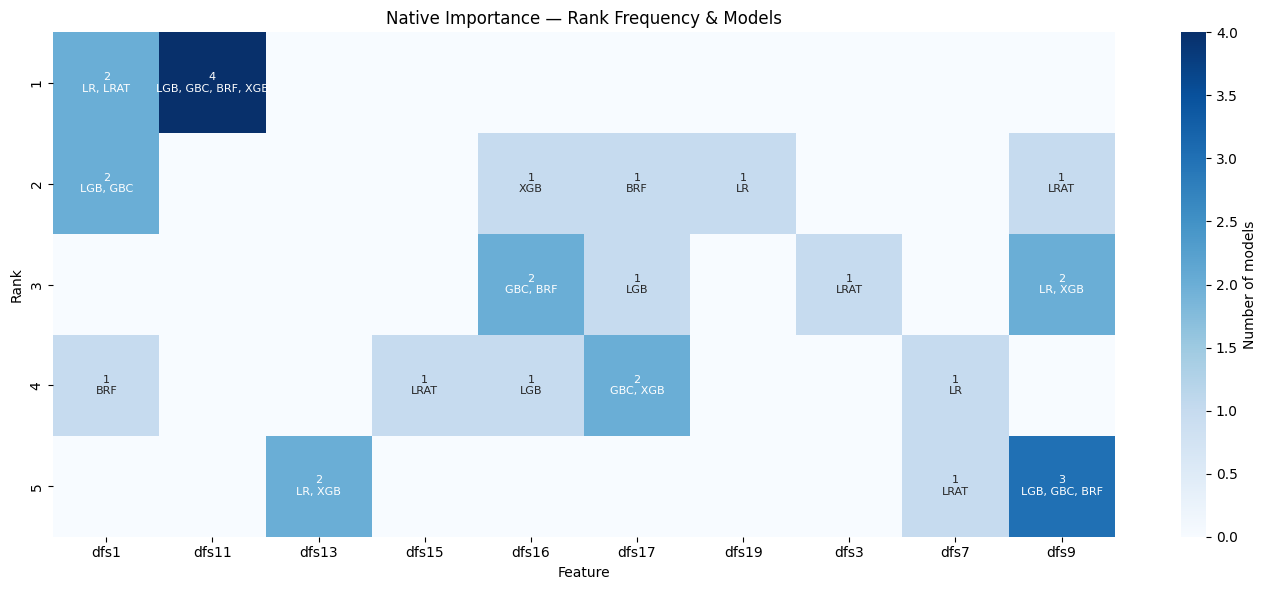

In [122]:
native_counts, native_annot = build_model_annotations(native_rank_df, top_n=5, model_abbrev=model_abbrev)
plot_rank_heatmap(native_counts, annot=native_annot, figsize=(14, 6), title='Native Importance — Rank Frequency & Models')